In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow import keras 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

In [6]:
df = pd.read_csv(r"../../Dataset/NCA Preprocessed/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [7]:
import sys
sys.path.append("../../")
from preprocessing.data_preprocessor import DataPreprocessor


preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train.shape)


Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [8]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test_norm = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test_norm.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


__C&W Attack__

In [25]:
def candw_attack_batch(model, x_ic, x_ctx, y_true, c=100.0, lr=0.02, steps=300, clip_min=-3.0, clip_max=3.0):
    """
    CW attack that maximizes error relative to true SOH
    """
    x_ic = tf.cast(x_ic, tf.float32)
    x_ctx = tf.cast(x_ctx, tf.float32)
    y_true = tf.cast(y_true, tf.float32)
    
    # Ensure y_true has correct shape
    if tf.rank(y_true) == 1:
        y_true = tf.expand_dims(y_true, axis=-1)

    c = tf.cast(c, tf.float32)
    clip_min = tf.cast(clip_min, tf.float32)
    clip_max = tf.cast(clip_max, tf.float32)

    # Get original predictions for reference only
    y_clean = tf.stop_gradient(model([x_ic, x_ctx], training=False))

    z = tf.Variable(tf.zeros_like(x_ic), trainable=True)
    optimizer = tf.keras.optimizers.Adam(learning_rate=float(lr))

    half_range = (clip_max - clip_min) / 2.0
    mid = (clip_max + clip_min) / 2.0
    
    axes = tf.range(1, tf.rank(x_ic))

    for _ in range(int(steps)):
        with tf.GradientTape() as tape:
            x_adv = tf.tanh(z) * half_range + mid
            y_adv = model([x_adv, x_ctx], training=False)

            # Maximize MSE relative to TRUE y
            mse = tf.reduce_mean(tf.square(y_true - y_adv))
            
            # L2 distortion
            l2 = tf.reduce_mean(
                tf.sqrt(tf.reduce_sum(tf.square(x_adv - x_ic), axis=axes) + 1e-12)
            )

            # Loss: minimize distortion, maximize MSE
            loss = l2 - c * mse

        grads = tape.gradient(loss, z)
        if grads is not None:
            grads = tf.where(tf.math.is_finite(grads), grads, tf.zeros_like(grads))
            grads = tf.clip_by_value(grads, -1.0, 1.0)  # Stability
            optimizer.apply_gradients([(grads, z)])

    return tf.tanh(z) * half_range + mid


In [ ]:
from tabulate import tabulate
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

def attack_eval(
    model,
    X_ic_test,
    X_context_test,
    y_test_norm,
    y_std,
    y_mean,
    attack_weight,   # maps from c
    lr,
    steps,           # maps from num_iter
    attack_fn,
    clip_min,
    clip_max,
    model_name="",
    plot=True
):
    # New candw_attack_batch signature: no y_test argument
    X_ic_test_adv = attack_fn(
        model=model,
        x_ic=X_ic_test,
        x_ctx=X_context_test,
        y_true = y_test_norm,
        c=attack_weight,
        lr=lr,
        steps=steps,
        clip_min=clip_min,
        clip_max=clip_max
    )

    # If tf.Tensor returned, convert for predict
    if hasattr(X_ic_test_adv, "numpy"):
        X_ic_test_adv = X_ic_test_adv.numpy()

    y_pred_norm = model.predict([X_ic_test, X_context_test], verbose=0).flatten()
    y_pred_adv_norm = model.predict([X_ic_test_adv, X_context_test], verbose=0).flatten()

    y_test = y_test_norm * y_std + y_mean
    y_pred = y_pred_norm * y_std + y_mean
    y_pred_adv = y_pred_adv_norm * y_std + y_mean

    mae_clean = mean_absolute_error(y_test, y_pred)
    mae_adv = mean_absolute_error(y_test, y_pred_adv)
    delta_mae = mae_adv - mae_clean

    mape_clean = mean_absolute_percentage_error(y_test, y_pred)
    mape_adv = mean_absolute_percentage_error(y_test, y_pred_adv)

    rel_robustness = (r2_score(y_test, y_pred_adv) - r2_score(y_test, y_pred))

    if plot:
        plt.figure(figsize=(16, 6))
        plt.subplot(1, 2, 1)
        plt.scatter(y_test, y_pred, alpha=0.5)
        min_val = min(y_test.min(), y_pred.min())
        max_val = max(y_test.max(), y_pred.max())
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.title(f"{model_name} - Clean")
        plt.xlabel("True SOH")
        plt.ylabel("Predicted SOH")
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.scatter(y_test, y_pred_adv, alpha=0.5, color="orange")
        plt.plot([min_val, max_val], [min_val, max_val], "r--")
        plt.title(f"{model_name} - Attacked (c={attack_weight}, steps={steps}, lr={lr})")
        plt.xlabel("True SOH")
        plt.ylabel("Predicted SOH")
        plt.grid()
        plt.show()

    return {
        "MAE_clean": mae_clean,
        "MAE_adv": mae_adv,
        "ΔMAE": delta_mae,
        "MAPE_clean": mape_clean,
        "MAPE_adv": mape_adv
    }


def run_attack_evaluation_grid(
    model,
    model_name,
    attack_fn,                # candw_attack_batch
    X_ic_test,
    X_context_test,
    y_test_norm,
    y_std,
    y_mean,
    attack_weight_values,     # list like [10, 50, 100]
    step_values,              # list like [50, 100, 200]
    lr,
    clip_min,
    clip_max,
    plot=False
):
    results = []

    for steps in step_values:
        for attack_weight in attack_weight_values:
            res = attack_eval(
                model=model,
                X_ic_test=X_ic_test,
                X_context_test=X_context_test,
                y_test_norm=y_test_norm,
                y_std=y_std,
                y_mean=y_mean,
                attack_weight=attack_weight,
                lr=lr,
                steps=steps,
                attack_fn=attack_fn,
                clip_min=clip_min,
                clip_max=clip_max,
                model_name=model_name,
                plot=plot
            )

            results.append([
                attack_weight, steps,
                res["MAE_clean"], res["MAE_adv"], res["ΔMAE"],
                res["MAPE_clean"], res["MAPE_adv"]
            ])

    headers = ["attack_weight", "steps", "MAE (Clean)", "MAE (Attacked)", "ΔMAE", "MAPE (Clean)", "MAPE (Attacked)"]
    print(f"\nAdversarial Evaluation Results - {model_name}")
    print(tabulate(results, headers=headers, floatfmt=".4f"))
    return results


In [17]:
from tqdm import tqdm 

batch_size = 32

y_train_tf = y_train.reshape(-1,1).astype(np.float32)
y_test_tf = y_test_norm.reshape(-1,1).astype(np.float32)

train_dataset = tf.data.Dataset.from_tensor_slices(
    (X_ic_train.astype(np.float32),X_context_train.astype(np.float32),
     y_train_tf)).shuffle(buffer_size=len(X_ic_train)).batch(batch_size)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (X_ic_test.astype(np.float32), X_context_test.astype(np.float32),
    y_test_tf)).batch(batch_size)

In [12]:
clip_min = np.percentile(X_ic_train, 0.5)
clip_max = np.percentile(X_ic_train, 99.5)

__CNN + LSTM__

--------
CNN+LSTM
--------


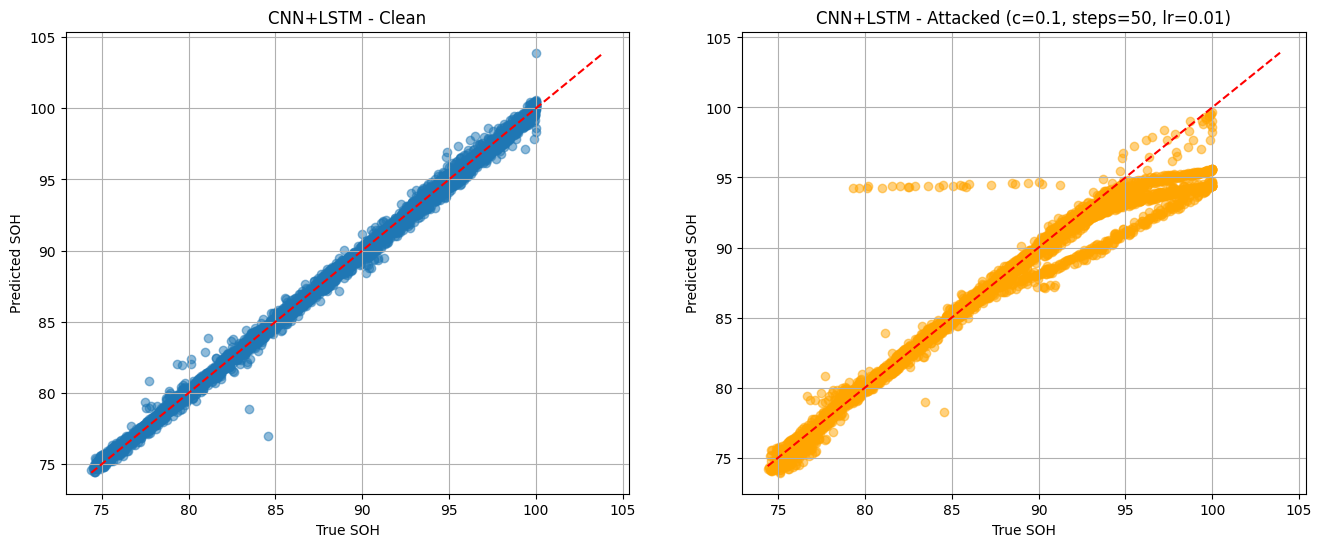

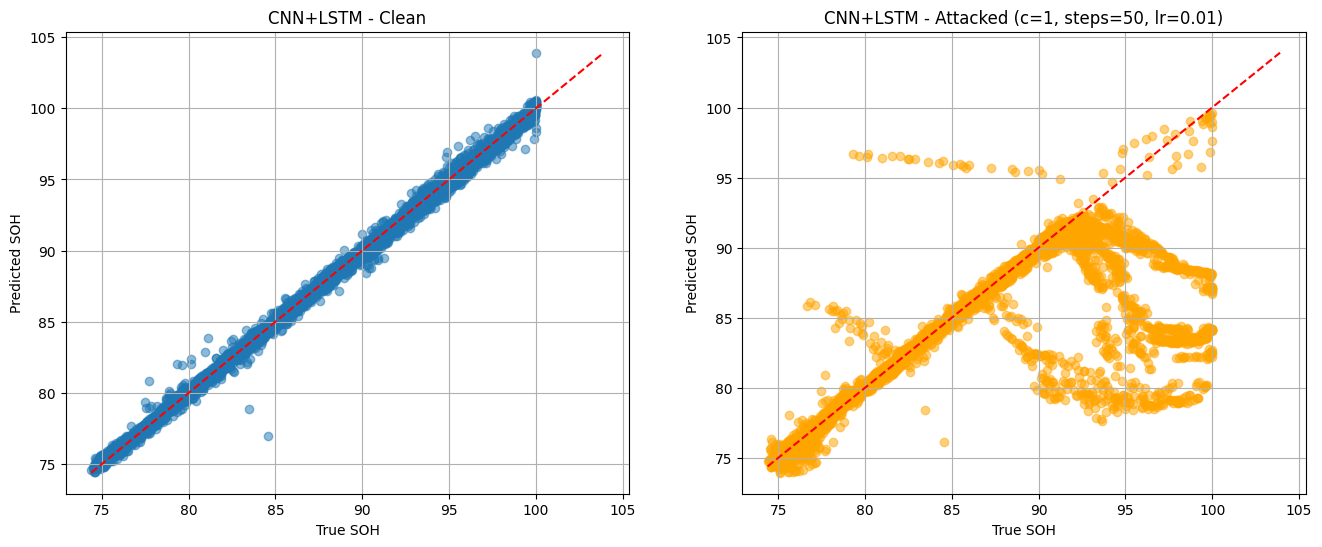

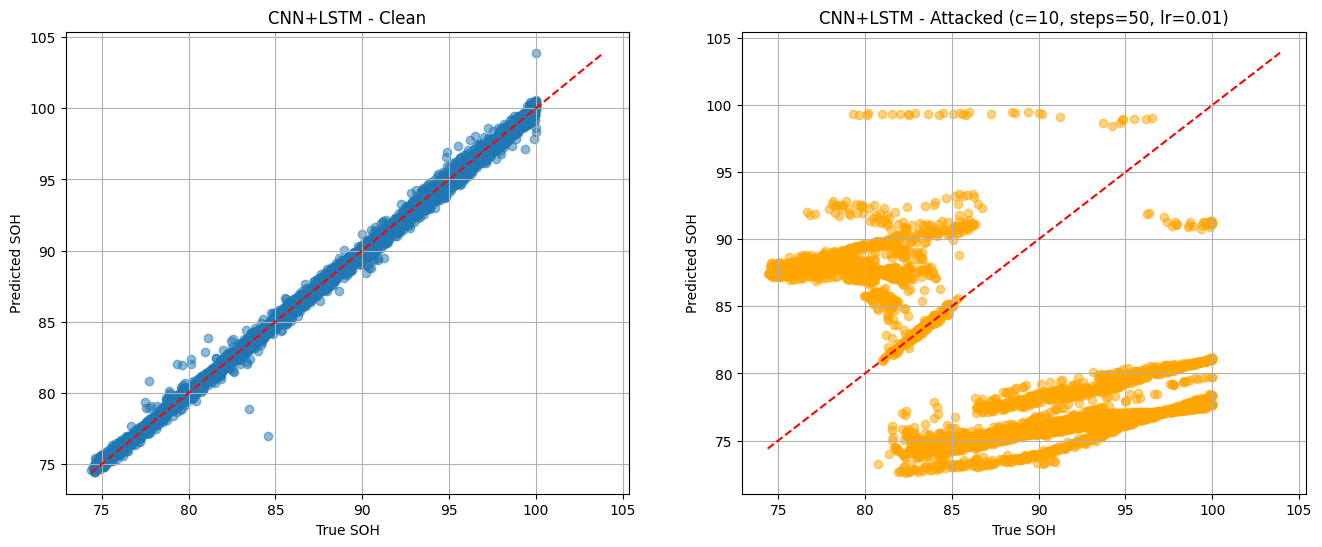

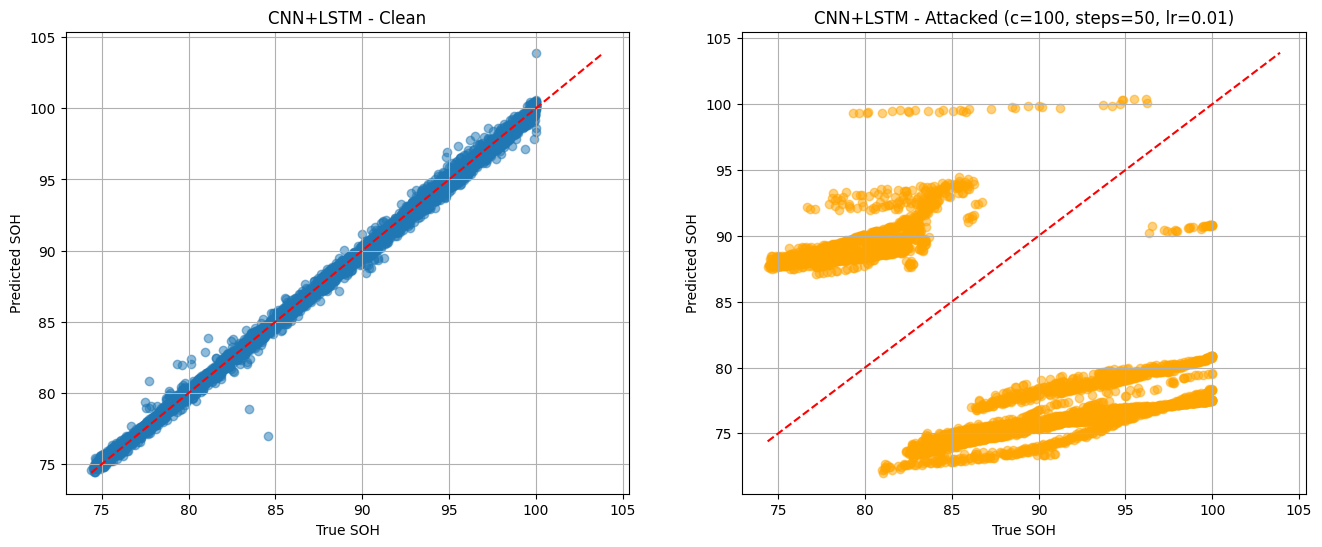

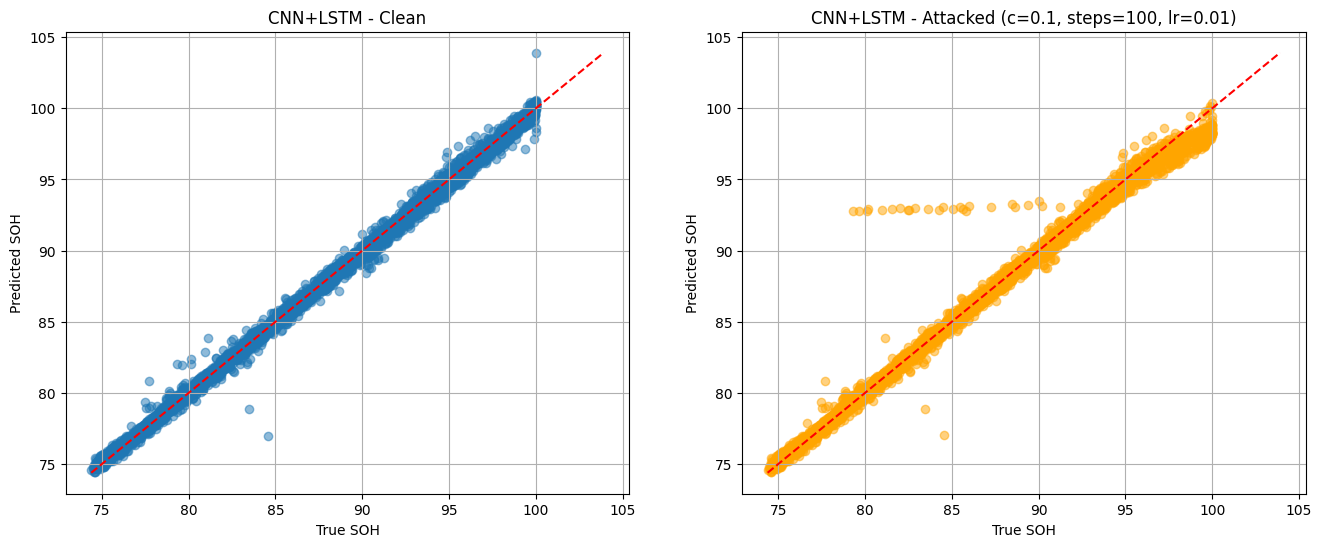

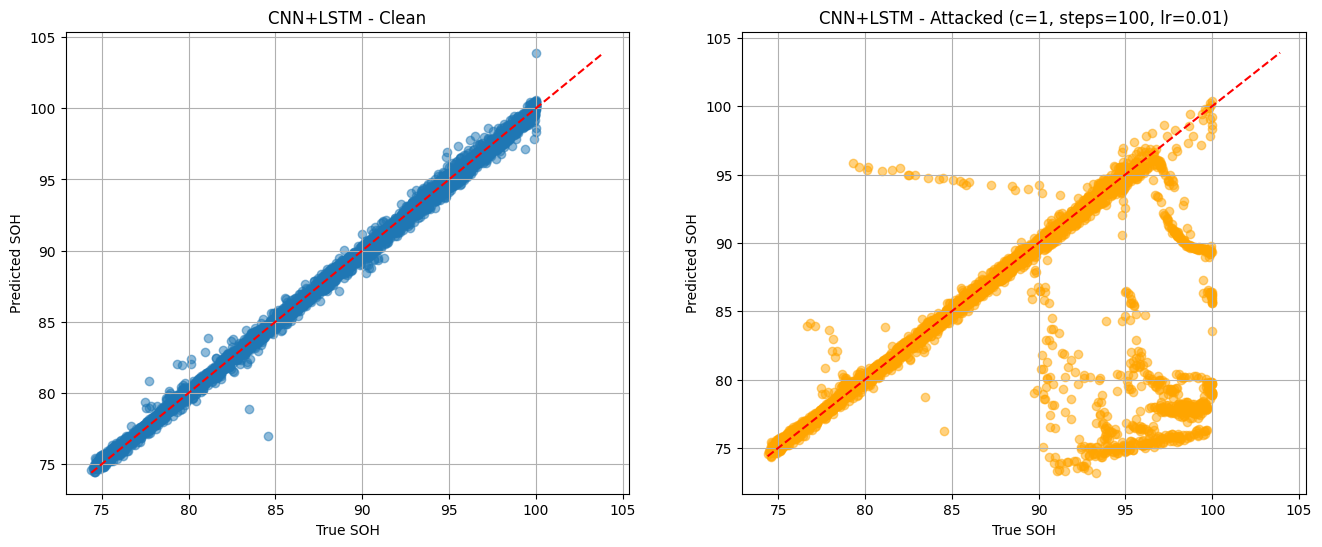

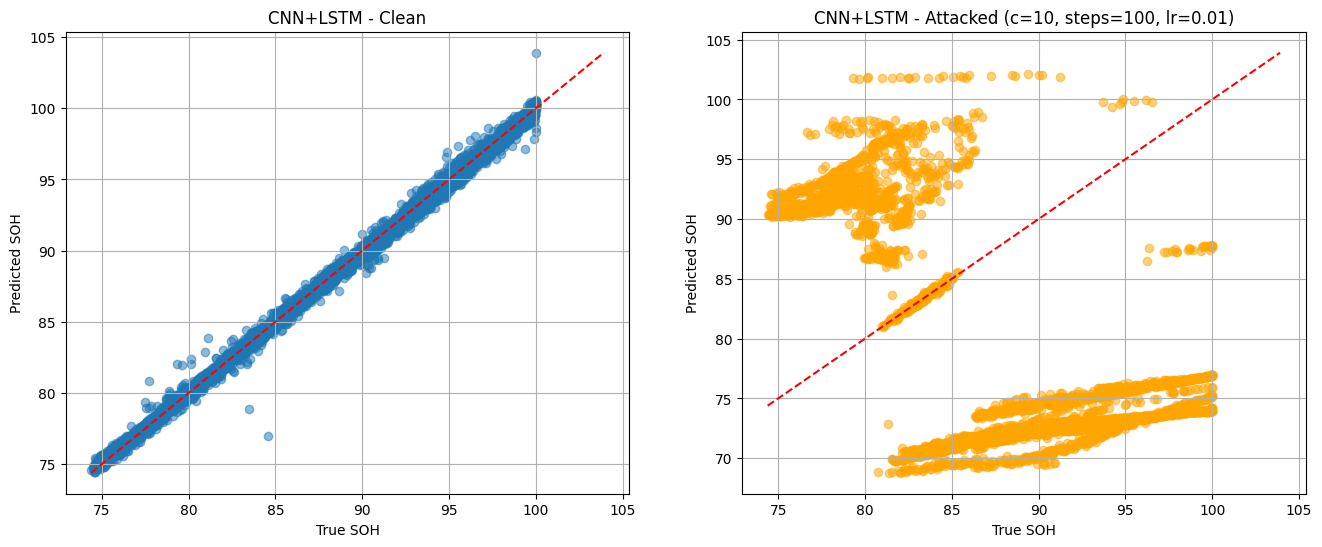

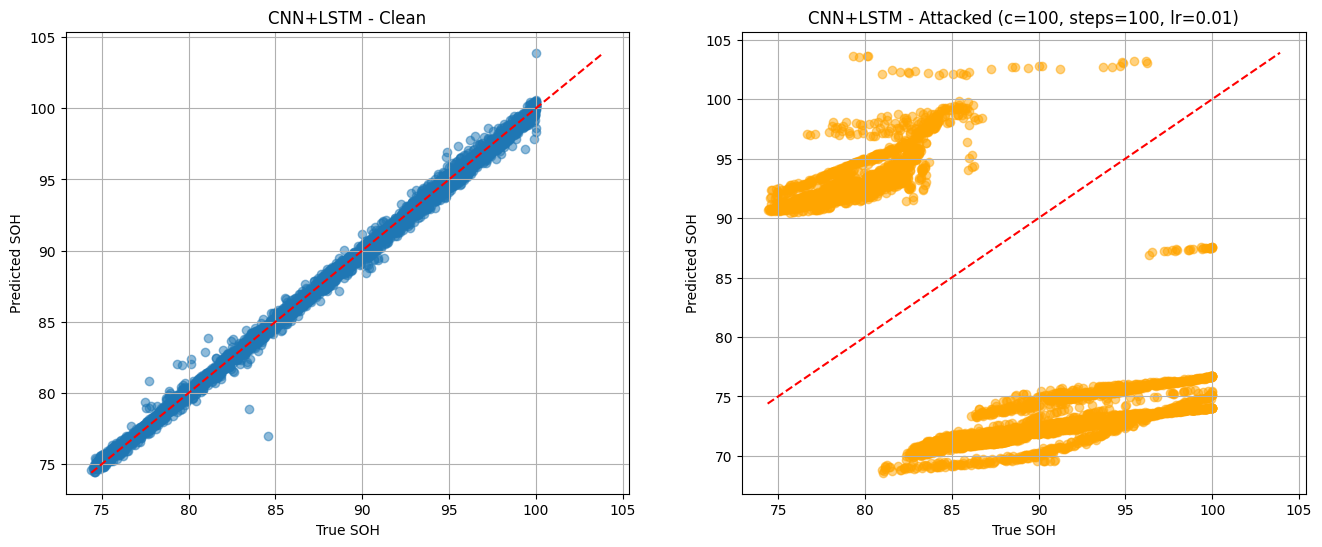

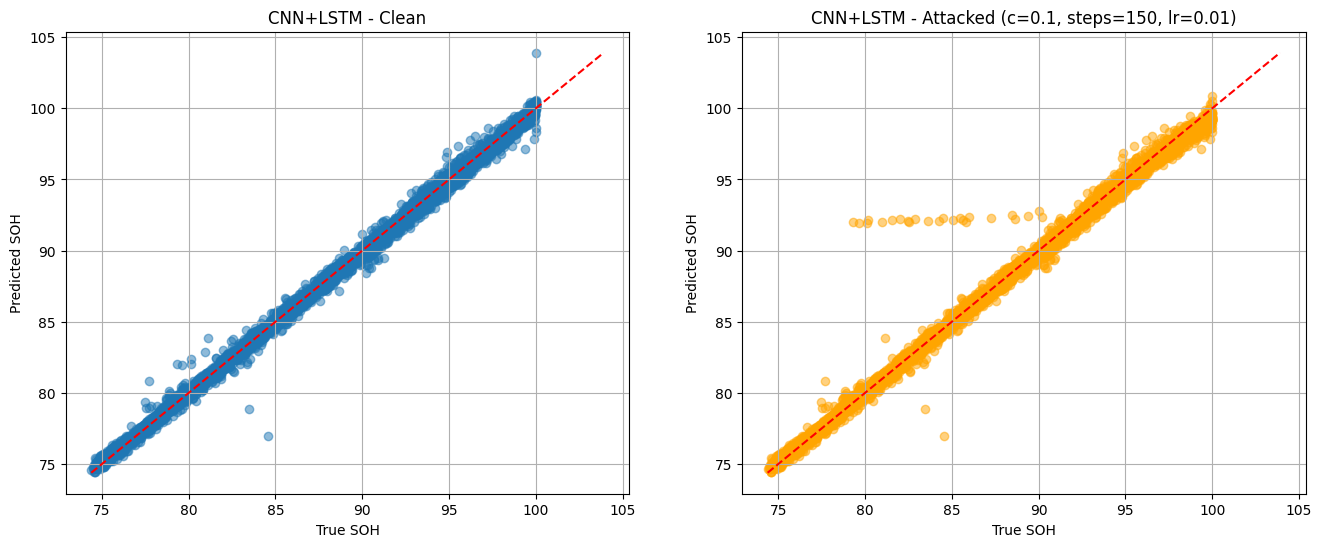

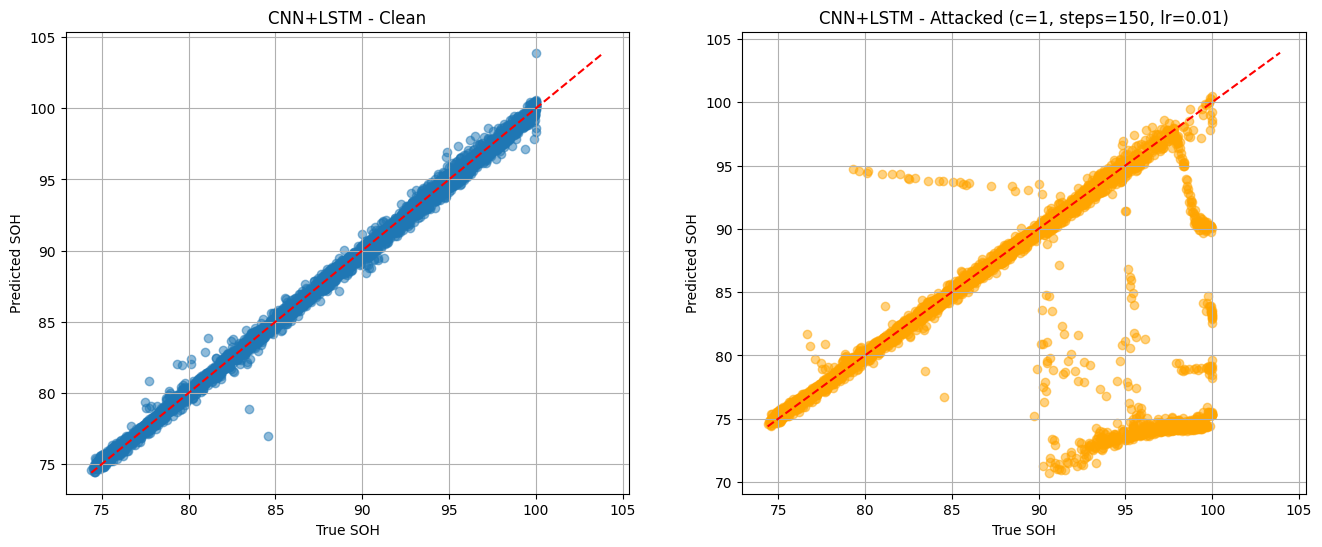

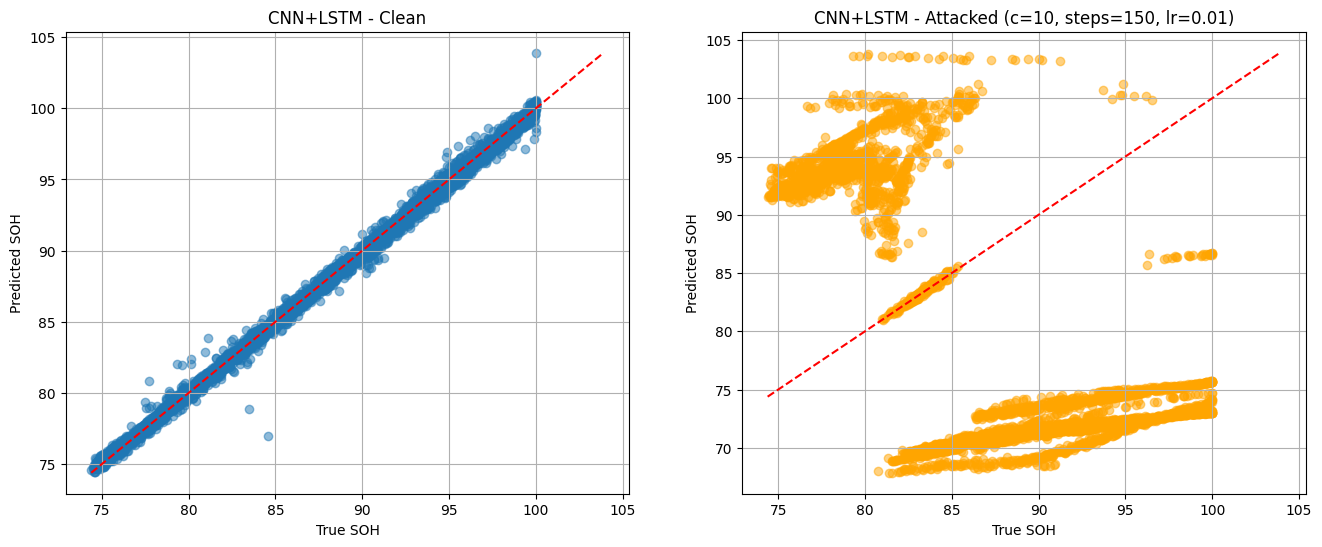

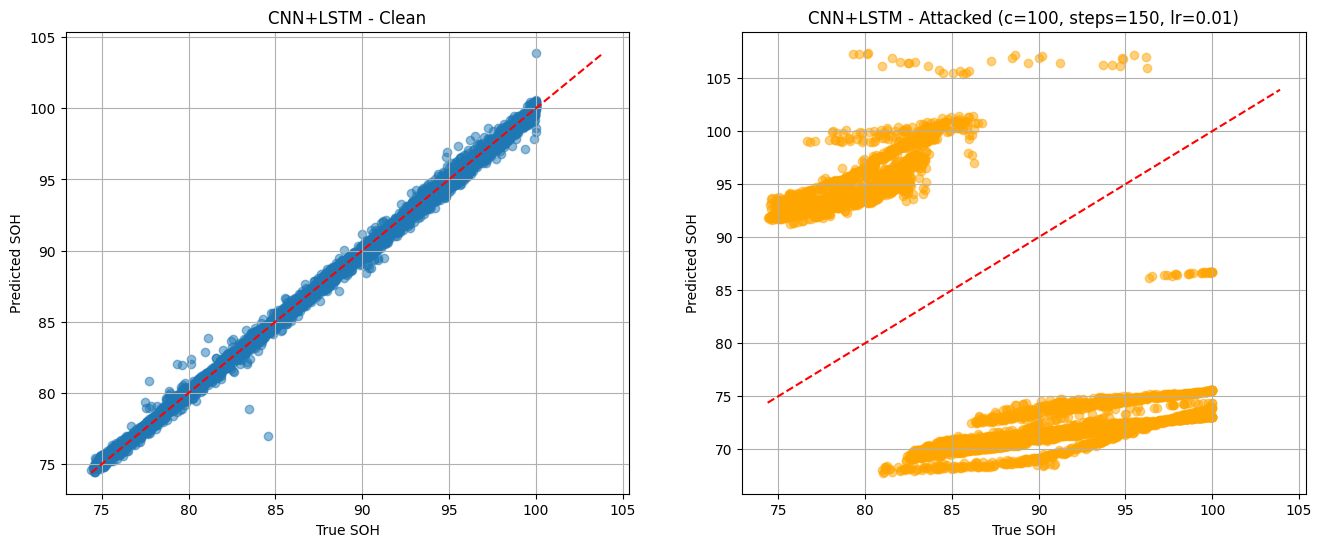

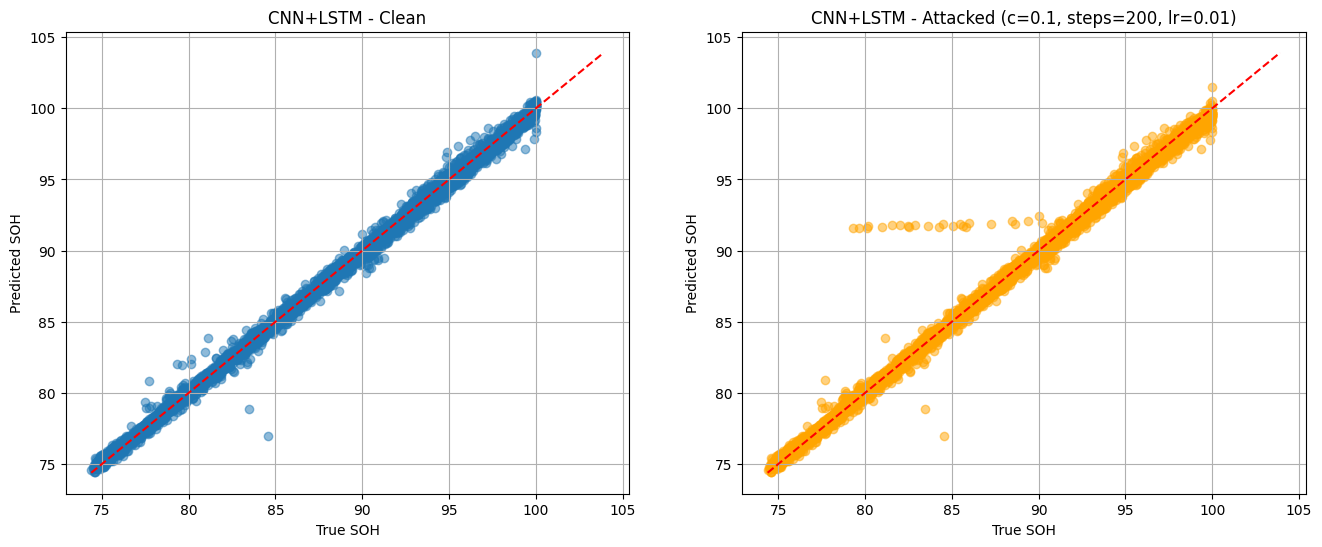

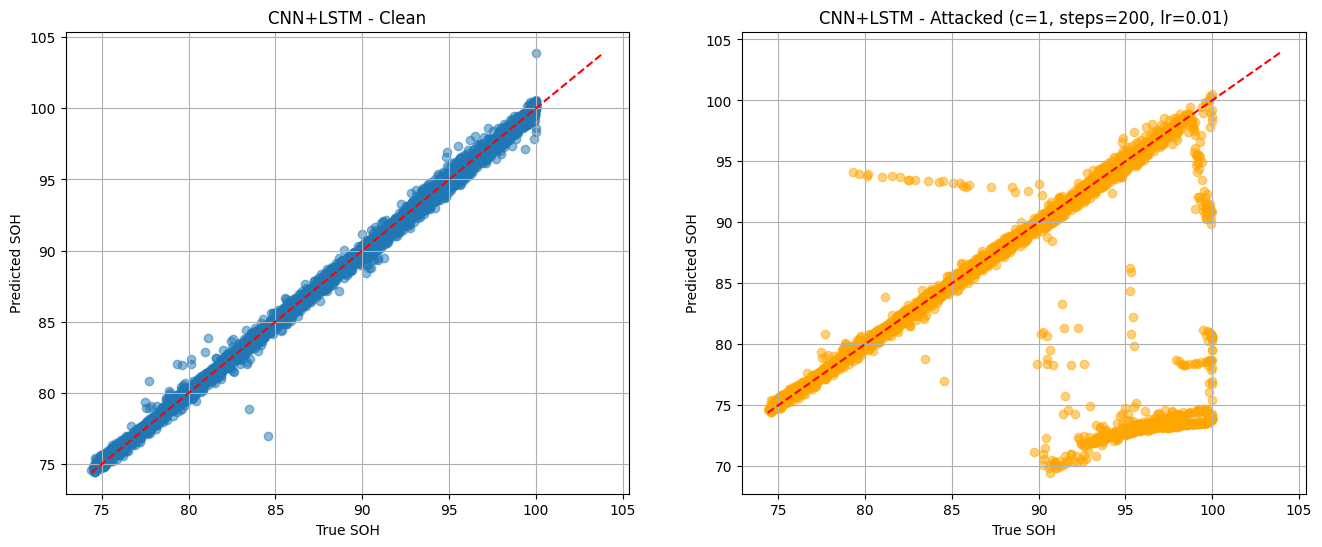

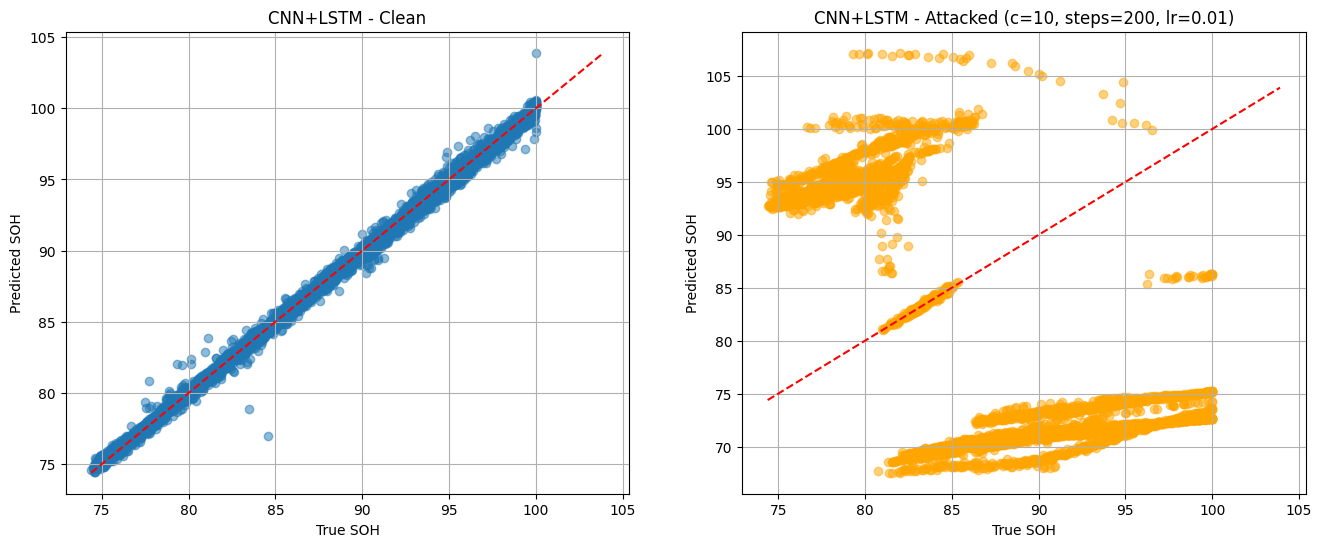

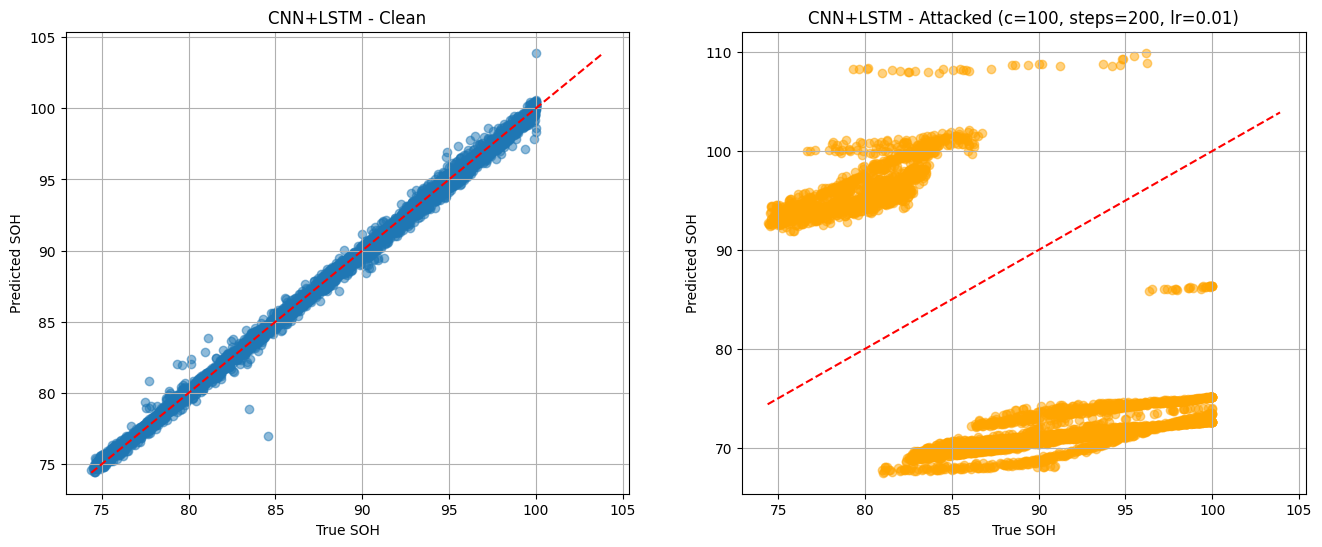

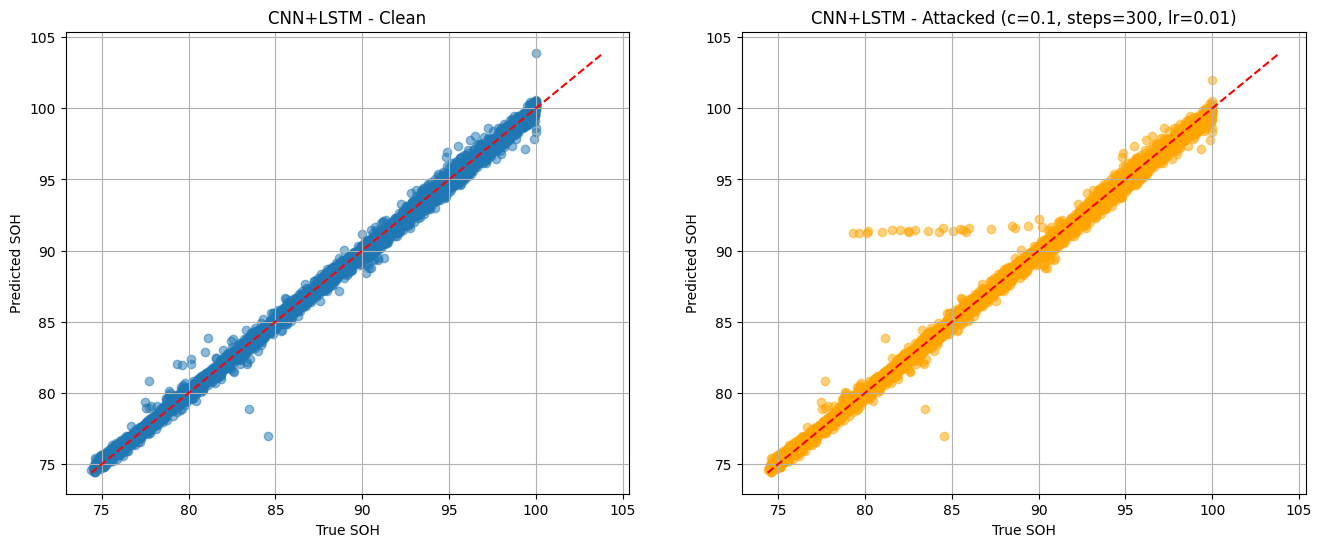

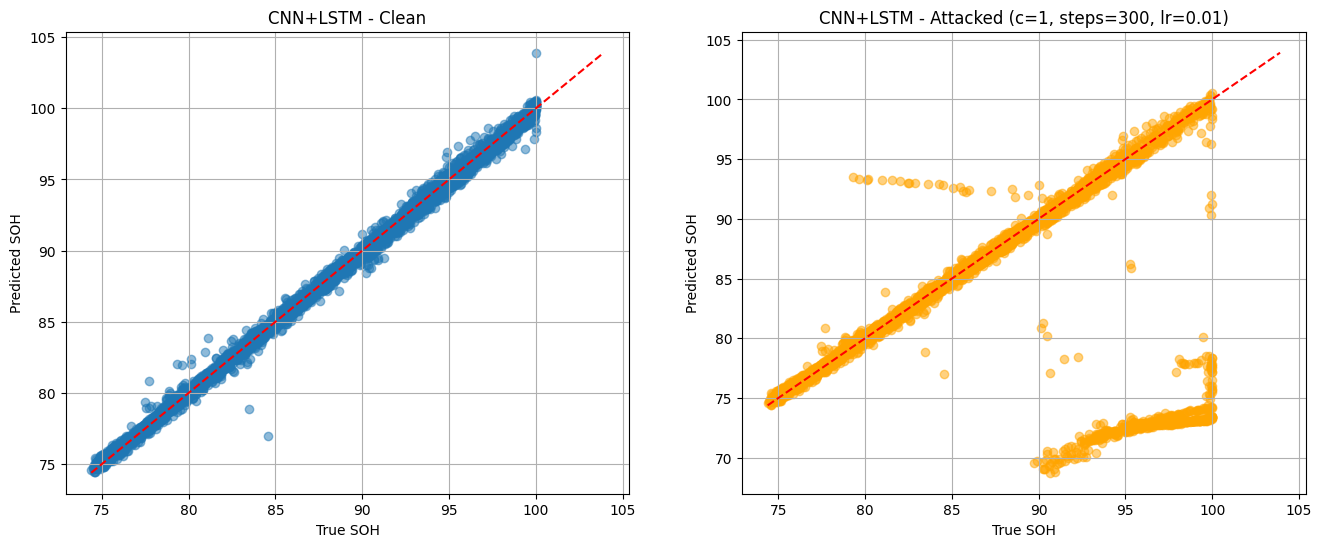

ERROR:tensorflow:==================================
Object was never used (type <class 'tensorflow.python.ops.tensor_array_ops.TensorArray'>):
If you want to mark it as used call its "mark_used()" method.
It was originally created here:
  File "c:\Users\saman\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend\tensorflow\rnn.py", line 418, in <genexpr>
    output_ta_t = tuple(  File "c:\Users\saman\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\util\tf_should_use.py", line 288, in wrapped
    return _add_should_use_warning(fn(*args, **kwargs),


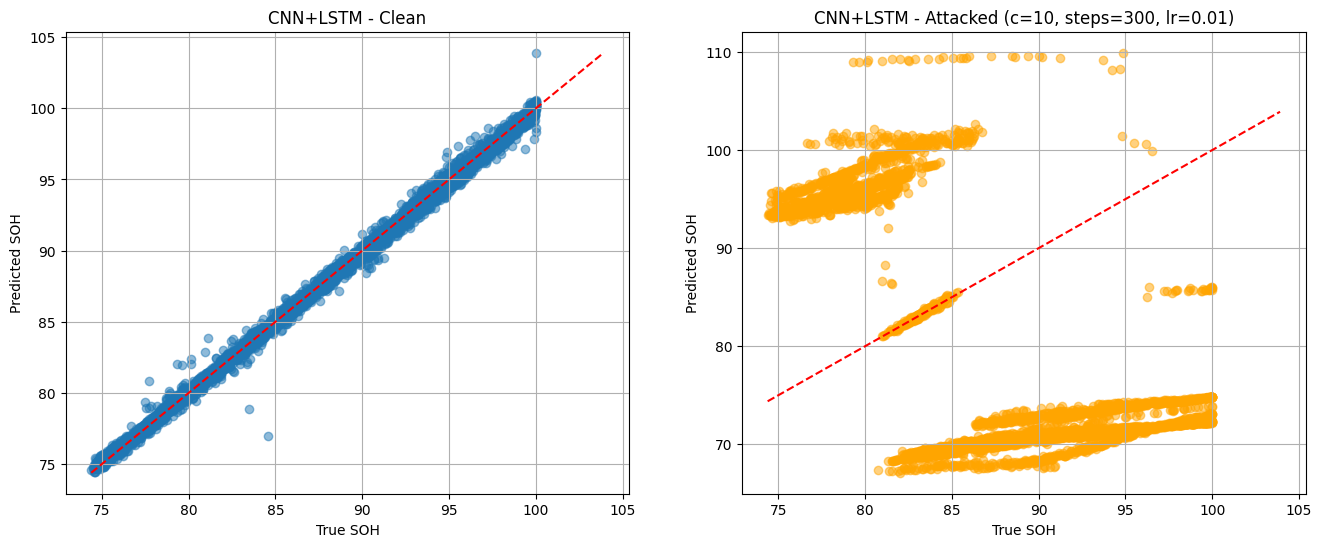

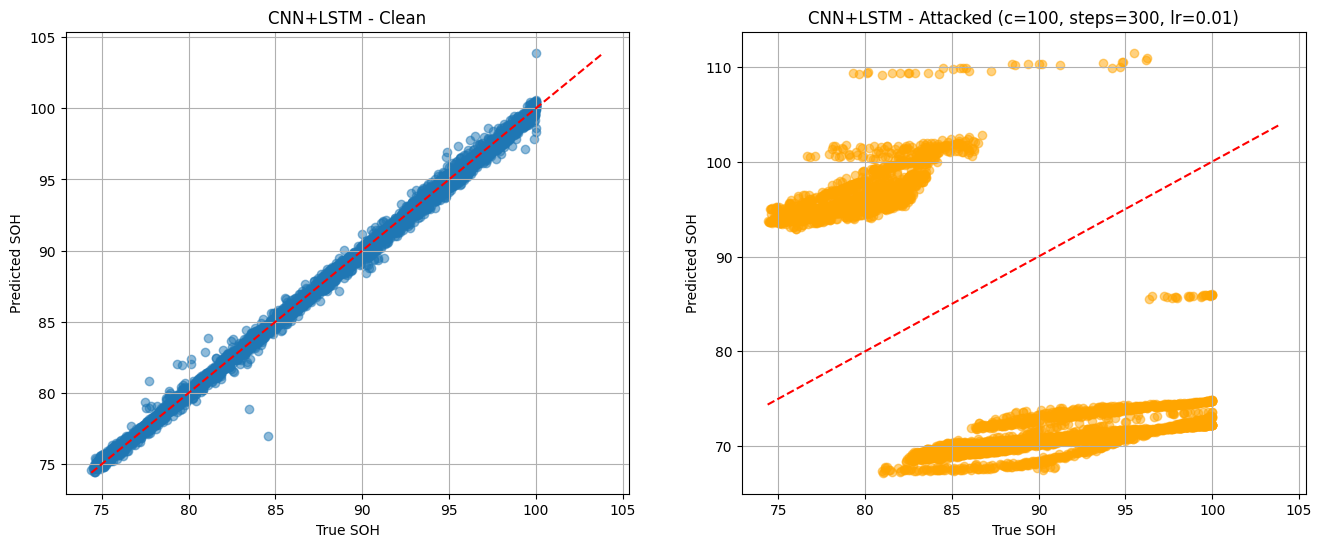

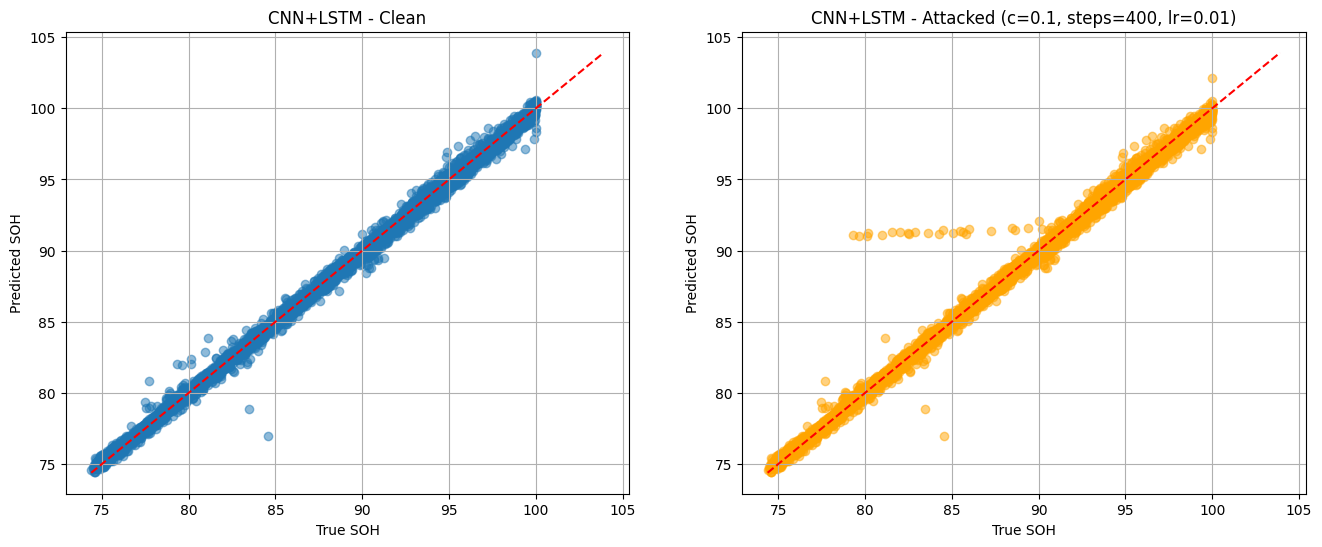

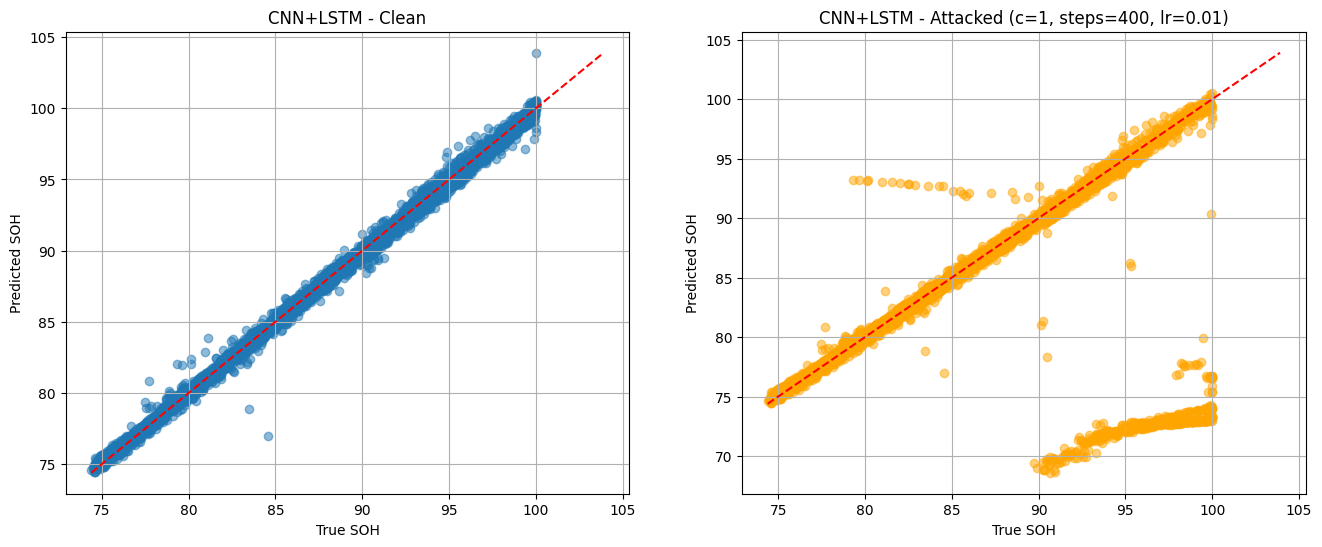

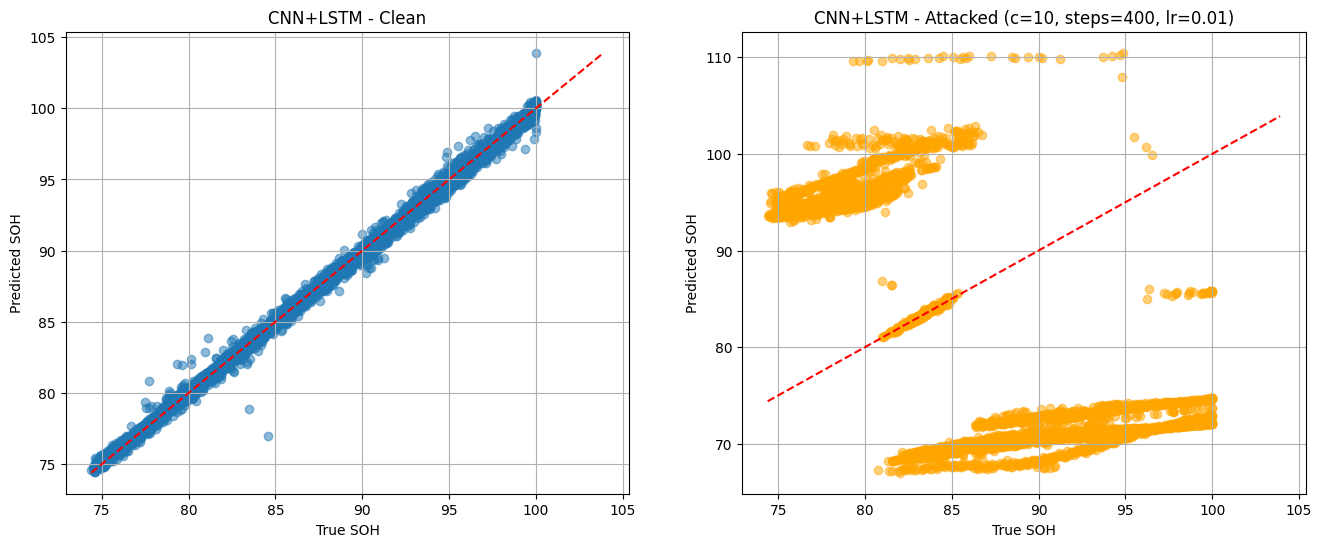

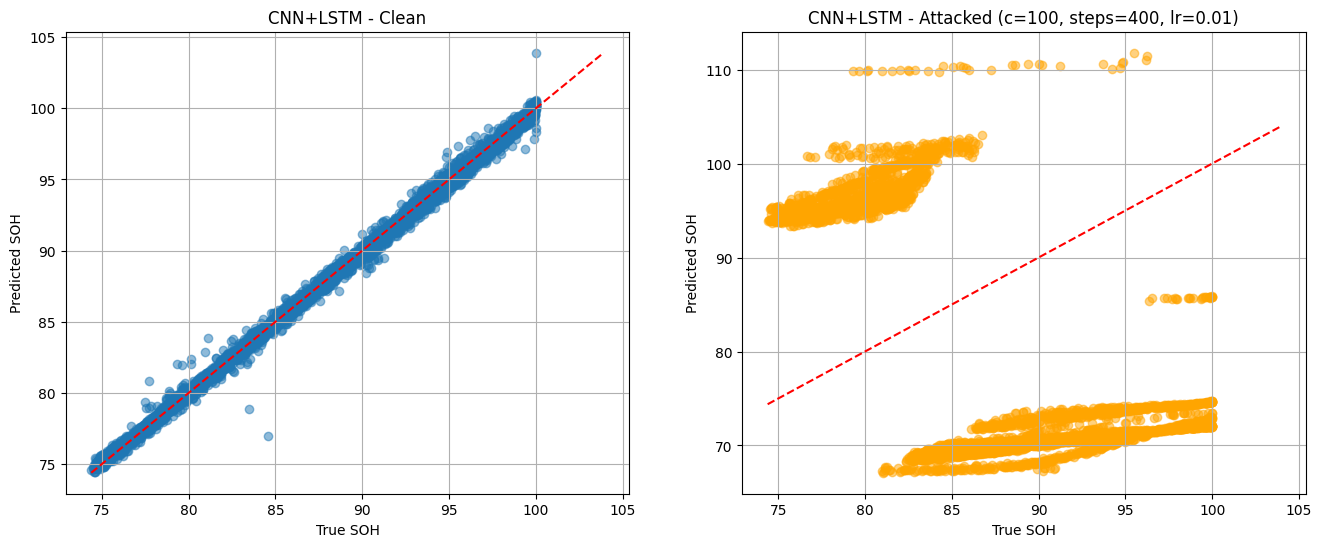


Adversarial Evaluation Results - CNN+LSTM
  attack_weight    steps    MAE (Clean)    MAE (Attacked)     ΔMAE    MAPE (Clean)    MAPE (Attacked)
---------------  -------  -------------  ----------------  -------  --------------  -----------------
         0.1000       50         0.2723            0.9088   0.6365          0.0031             0.0098
         1.0000       50         0.2723            2.7643   2.4919          0.0031             0.0292
        10.0000       50         0.2723           12.0798  11.8075          0.0031             0.1367
       100.0000       50         0.2723           12.8397  12.5673          0.0031             0.1458
         0.1000      100         0.2723            0.3787   0.1063          0.0031             0.0043
         1.0000      100         0.2723            2.7221   2.4497          0.0031             0.0285
        10.0000      100         0.2723           15.6547  15.3824          0.0031             0.1780
       100.0000      100         0.2723

In [28]:
print("--------")
print("CNN+LSTM")
print("--------")

cnn_lstm = keras.models.load_model(r"../../Models/CNN_LSTM_NT.keras") 

attack_results_cnn_lstm = run_attack_evaluation_grid(
    model=cnn_lstm,
    model_name="CNN+LSTM",
    attack_fn=candw_attack_batch,
    X_ic_test=X_ic_test,
    X_context_test=X_context_test,
    y_test_norm=y_test_tf,
    y_std=y_std,
    y_mean=y_mean,
    attack_weight_values=[0.1, 1, 10, 100],
    step_values=[50, 100, 150, 200, 300, 400],
    lr=0.01,
    clip_min=clip_min,
    clip_max=clip_max,
    plot=True
)



__CNN + GRU__

In [ ]:
print("---------")
print("CNN + GRU")
print("---------")

cnn_gru = keras.models.load_model(r"F:\College\SEM 8\Project Phase 2\Models\best_cnn_gru_1.keras")
attack_eval(cnn_gru, X_ic_test, X_context_test, y_test, attack_weight=2.0 , lr = 0.001, steps = 250, clip_min = -3.0, clip_max = 3.0, model_name="CNN+GRU")

In [ ]:
rcn = keras.models.load_model(r"F:\College\SEM 8\Project Phase 2\Models\best_rcn.keras")

print("---")
print("RCN")
print("---")

attack_eval(rcn, X_ic_test, X_context_test, y_test, attack_weight=1.0 , lr = 0.01, steps = 100, clip_min = -3.0, clip_max = 3.0, model_name="RCN")

__CNN__

In [ ]:
print("---")
print("CNN")
print("---")

cnn = keras.models.load_model(r"F:\College\SEM 8\Project Phase 2\Models\best_cnn.keras")

attack_eval(cnn, X_ic_test, X_context_test, y_test, attack_weight=1.0 , lr = 0.01, steps = 100, clip_min = -3.0, clip_max = 3.0, model_name="CNN")

In [ ]:
idx = 100   

orig_ic = X_ic_test[idx].reshape(-1)     
orig_ctx = X_context_test[idx].reshape(1,-1)
orig_true = y_test[idx]

adv_ic = candw_attack(
    cnn_gru,
    X_ic_test[idx:idx+1],     
    X_context_test[idx:idx+1],
    y_test[idx:idx+1]
)

adv_ic = adv_ic.reshape(-1)

y_pred_orig = cnn_gru.predict([X_ic_test[idx:idx+1], X_context_test[idx:idx+1]])[0][0]
y_pred_adv  = cnn_gru.predict([adv_ic.reshape(1,-1,1), X_context_test[idx:idx+1]])[0][0]

y_pred_orig = y_pred_orig * y_std + y_mean
y_pred_adv = y_pred_adv * y_std + y_mean

orig_true = orig_true * y_std + y_mean

print("Original pred:", y_pred_orig)
print("Adversarial pred:", y_pred_adv)
print("True value:", orig_true)


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(orig_ic, marker='o', label="Original IC")
plt.plot(adv_ic, marker='x', label="Attacked IC (C&W attack)")
plt.title("IC Feature Distortion Example")
plt.xlabel("IC Bin Index")
plt.ylabel("IC Value (normalized)")
plt.legend()
plt.grid(True)
plt.show()
